In [57]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
from functools import partial
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'

import importlib
importlib.reload(observables)
from src.observables import denoise_rolling as dr
drp = partial(dr, window=2)

TeNPy version: 1.1.0


In [12]:
# REQ_DATA = 't_1.00_U_0.10_Vpp_0.800/v2/'
# REQ_DATA = 't_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_100/'
REQ_DATA = 'v2fwd/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_100/'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_100" in f]
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params,
        'converged' : metadata['converged'], 
        'E' : metadata['E'], 
        'Sz' : metadata['Sz'],
        'Ntot' : metadata["Ntot"], 
        'xi' : metadata['xi'],
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df.head()

,psi,dV,mean_Sz,mean_fill,model_params,converged,E,Sz,Ntot,xi
31,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.0,-6.794326e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc...",True,-0.563028,"[-6.6102128210630205e-12, -6.978438971786054e-12]","[0.49963472391442565, 0.5003652760855741]",4.590626e+08
15,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.1,1.432953e-13,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.9000000000000004, ...",True,-0.558356,"[1.407519037344588e-13, 1.458386064205203e-13]","[0.500328401829151, 0.4996715981708496]",2.626312e+11
28,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.2,-1.010983e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...",True,-0.553847,"[-1.0047047118524786e-12, -1.0172611508567046e...","[0.5003049933426775, 0.4996950066573244]",3.585283e+10
26,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.3,1.059266e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc...",True,-0.549509,"[1.0410755267978299e-12, 1.0774567523136146e-12]","[0.5003499826907956, 0.4996500173092071]",2.251800e+15
36,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.4,-1.158711e-04,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...",True,-0.545357,"[-0.00011594831287374508, -0.00011579390681158...","[0.5001746753981045, 0.4998253246018967]",4.503600e+15


In [13]:
REQ_DATA200 = 'v2fwdchi200/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_200'
PATH_TO_REQ_DATA200 = os.path.join(DATA_ROOT, REQ_DATA200)
file_list = [os.path.join(PATH_TO_REQ_DATA200,f) for f in os.listdir(PATH_TO_REQ_DATA200) if "chimax_200" in f]
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params,
        'converged' : metadata['converged'], 
        'E' : metadata['E'], 
        'Sz' : metadata['Sz'],
        'Ntot' : metadata["Ntot"], 
        'xi' : metadata['xi'], 
    }
    return row_dict
    
df2 = pd.DataFrame([atomic_action(f) for f in file_list])
df2 = df2.sort_values('dV')
df2.head()

,psi,dV,mean_Sz,mean_fill,model_params,converged,E,Sz,Ntot,xi
4,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.0,1.150309e-13,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc...",True,-0.563190,"[1.091523312894564e-13, 1.2090940565691571e-13]","[0.5000763729577116, 0.4999236270422903]",1.286743e+15
14,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.1,-2.288584e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.9000000000000004, ...",True,-0.558507,"[-2.2758157552697264e-12, -2.3013525694512365e...","[0.5001064322076345, 0.4998935677923683]",-inf
42,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.2,5.255636e-13,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...",True,-0.553986,"[5.233053801474491e-13, 5.278217918794351e-13]","[0.4999027611463106, 0.5000972388536924]",6.433714e+14
39,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.3,-2.413072e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc...",True,-0.549633,"[-2.439990432105076e-12, -2.386153900561602e-12]","[0.4999609212597562, 0.5000390787402407]",1.125900e+15
2,"MPS, L=2, bc='infinite'.\nchi: [200, 200]\nsit...",3.4,-7.779430e-07,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...",True,-0.545457,"[-7.315208316979278e-07, -8.243651542860073e-07]","[0.49998303065386623, 0.500016969346133]",1.286743e+15


In [14]:
REQ_DATA300 = 'v2fwdchi300/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_300'
PATH_TO_REQ_DATA300 = os.path.join(DATA_ROOT, REQ_DATA300)
file_list = [os.path.join(PATH_TO_REQ_DATA300,f) for f in os.listdir(PATH_TO_REQ_DATA300) if "chimax_300" in f]
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params,
        'converged' : metadata['converged'], 
        'E' : metadata['E'], 
        'Sz' : metadata['Sz'],
        'Ntot' : metadata["Ntot"], 
        'xi' : metadata['xi'],
    }
    return row_dict
    
df3 = pd.DataFrame([atomic_action(f) for f in file_list])
df3 = df3.sort_values('dV')
df3.head()

,psi,dV,mean_Sz,mean_fill,model_params,converged,E,Sz,Ntot,xi
31,"MPS, L=2, bc='infinite'.\nchi: [300, 300]\nsit...",3.0,-7.020935e-11,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc...",True,-0.563226,"[-7.012650280715952e-11, -7.029220336387363e-11]","[0.5000919001845484, 0.49990809981545614]",5.629500e+14
41,"MPS, L=2, bc='infinite'.\nchi: [300, 300]\nsit...",3.1,-4.782868e-11,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.9000000000000004, ...",True,-0.558541,"[-3.749317296984878e-11, -5.816419238273489e-11]","[0.4999383560435022, 0.500061643956496]",2.814750e+14
21,"MPS, L=2, bc='infinite'.\nchi: [300, 300]\nsit...",3.2,-1.095615e-09,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...",True,-0.554018,"[-1.1289658007640258e-09, -1.0622650394190429e...","[0.5000744204562874, 0.499925579543711]",1.801440e+15
24,"MPS, L=2, bc='infinite'.\nchi: [300, 300]\nsit...",3.3,-8.255738e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc...",True,-0.549661,"[-8.177124069225316e-12, -8.334351684723275e-12]","[0.500080894546562, 0.49991910545344087]",1.926674e+13
32,"MPS, L=2, bc='infinite'.\nchi: [300, 300]\nsit...",3.4,-6.655109e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...",True,-0.545480,"[-6.666122831446306e-12, -6.644094411629368e-12]","[0.4999238255218356, 0.5000761744781647]",2.251800e+15


Text(0.5, 1.0, '$dV_* \\approx 3.55$')

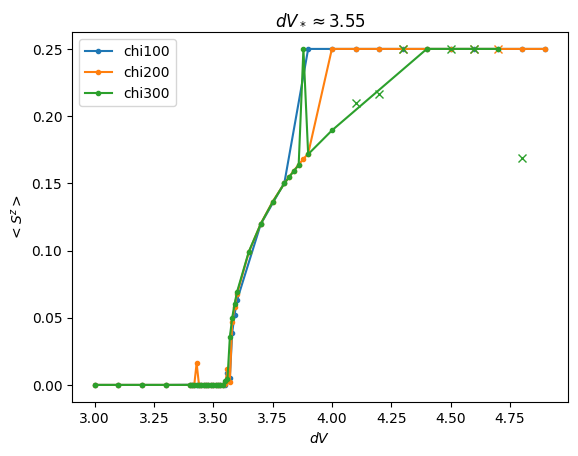

In [15]:
fig, ax = plt.subplots(1)
mask = df['converged']
ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_Sz']), ls='-', marker='.', c='C0', label='chi100')
ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_Sz']), ls='', marker='x', c='C0')
mask2 = df2['converged']
ax.plot(df2.loc[mask2, 'dV'], np.abs(df2.loc[mask2, 'mean_Sz']), ls='-', marker='.', c='C1', label='chi200')
ax.plot(df2.loc[~mask2, 'dV'], np.abs(df2.loc[~mask2, 'mean_Sz']), ls='', marker='x', c='C1')
mask3 = df3['converged']
ax.plot(df3.loc[mask3, 'dV'], np.abs(df3.loc[mask3, 'mean_Sz']), ls='-', marker='.', c='C2', label='chi300')
ax.plot(df3.loc[~mask3, 'dV'], np.abs(df3.loc[~mask3, 'mean_Sz']), ls='', marker='x', c='C2')
ax.legend()
ax.set_ylabel(r'$<S^z>$')
ax.set_xlabel(r'$dV$')
ax.set_title(r'$dV_* \approx 3.55$')
# ax.set_xlim(3.500,3.6)
# ax.set_ylim(None, 0.1)
# ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_fill']), ls='-', marker='.', c='C1')
# ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_fill']), ls='', marker='x', c='r')
# ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'E']), ls='-', marker='.', c='C2')
# ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'E']), ls='', marker='x', c='r')

Text(0.5, 0, '$dV$')

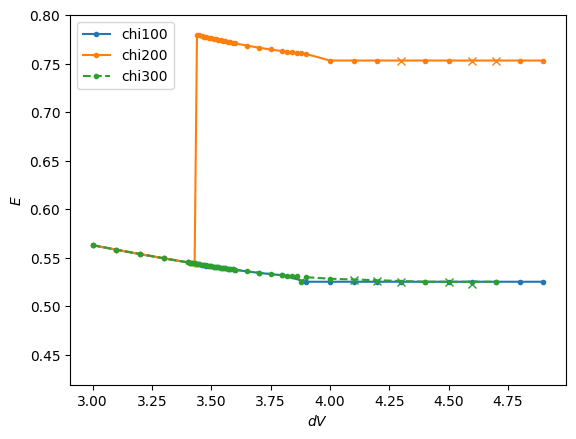

In [16]:
fig2, ax2 = plt.subplots()
ax2.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'E']), ls='-', marker='.', c='C0', label='chi100')
ax2.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'E']), ls='', marker='x', c='C0')
ax2.plot(df2.loc[mask2, 'dV'], np.abs(df2.loc[mask2, 'E']), ls='-', marker='.', c='C1', label='chi200')
ax2.plot(df2.loc[~mask2, 'dV'], np.abs(df2.loc[~mask2, 'E']), ls='', marker='x', c='C1')
ax2.plot(df3.loc[mask3, 'dV'], np.abs(df3.loc[mask3, 'E']), ls='--', marker='.', c='C2', label='chi300')
ax2.plot(df3.loc[~mask3, 'dV'], np.abs(df3.loc[~mask3, 'E']), ls='', marker='x', c='C2')
ax2.legend()
# ax2.set_xlim(3.500,3.6)
ax2.set_ylim(None, 0.8)
# ax2.set_yscale('log')
ax2.set_ylabel(r'$E$')
ax2.set_xlabel(r'$dV$')


In [17]:
pmdV = 3.1
fmdV = 3.8
critdV = 3.55
serpm100, serfm100, sercrit100 = df[np.isclose(df['dV'], pmdV)], df[np.isclose(df['dV'], fmdV)], df[np.isclose(df['dV'], critdV)]
serpm200, serfm200, sercrit200 = df2[np.isclose(df2['dV'], pmdV)], df2[np.isclose(df2['dV'], fmdV)], df2[np.isclose(df2['dV'], critdV)]
serpm300, serfm300, sercrit300 = df3[np.isclose(df3['dV'], pmdV)], df3[np.isclose(df3['dV'], fmdV)], df3[np.isclose(df3['dV'], critdV)]
allsers = [serpm100, sercrit100, serfm100, serpm200, sercrit200, serfm200, serpm300, sercrit300, serfm300,]
for ser in allsers: 
    assert ser['converged'].iloc[0] == True , "Pick only converged WFS!!!!"
# serpm100['psi'].iloc[0]

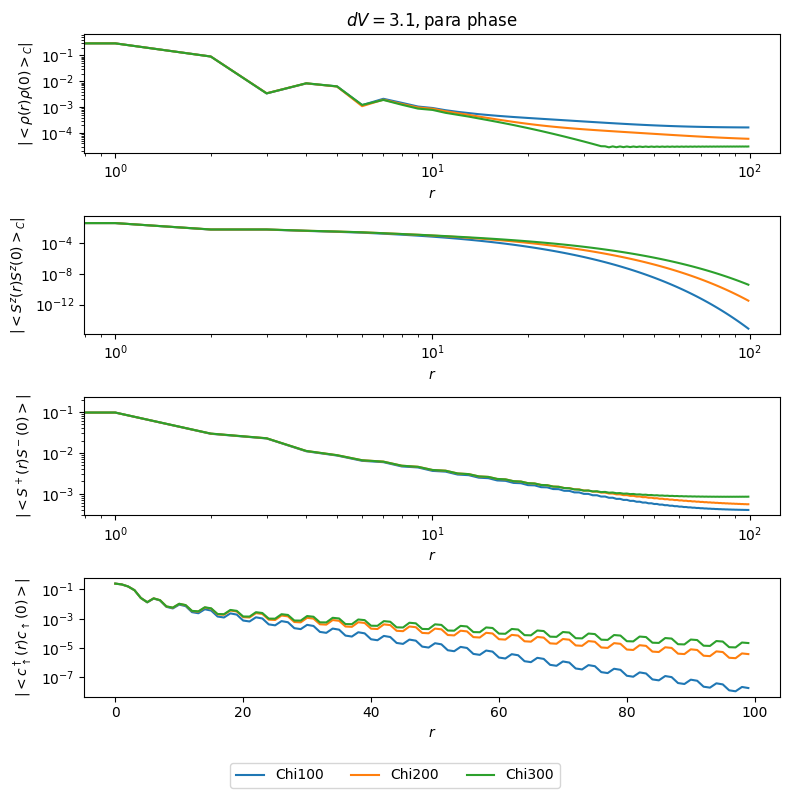

In [73]:
distrangepm = 100
xvalspm = np.arange(distrangepm)
fig3, ax3 = plt.subplots(4, figsize=(8,8))
fig3.subplots_adjust(hspace=0.2)
#charge
ax3[0].plot(xvalspm, drp(np.abs(observables.charge_corr(serpm100['psi'].iloc[0], length=distrangepm, connected=True))), c='C0', label='Chi100')
ax3[0].plot(xvalspm, drp(np.abs(observables.charge_corr(serpm200['psi'].iloc[0], length=distrangepm, connected=True))), c='C1', label='Chi200')
ax3[0].plot(xvalspm, drp(np.abs(observables.charge_corr(serpm300['psi'].iloc[0], length=distrangepm, connected=True))), c='C2', label='Chi300')
ax3[0].set_yscale('log')
ax3[0].set_xscale('log')
ax3[0].set_xlabel(r'$r$')
ax3[0].set_ylabel(r'$|<\rho(r)\rho(0)>_C|$')
ax3[0].set_title(rf'$dV = {pmdV:.3}, \text{{para phase}}$')
# ax3[0].legend()

#spin
ax3[1].plot(xvalspm, drp(np.abs(observables.SzSz_corr(serpm100['psi'].iloc[0], length=distrangepm, connected=True))), c='C0', label='Chi100')
ax3[1].plot(xvalspm, drp(np.abs(observables.SzSz_corr(serpm200['psi'].iloc[0], length=distrangepm, connected=True))), c='C1', label='Chi200')
ax3[1].plot(xvalspm, drp(np.abs(observables.SzSz_corr(serpm300['psi'].iloc[0], length=distrangepm, connected=True))), c='C2', label='Chi300')
ax3[1].set_yscale('log')
ax3[1].set_xscale('log')
ax3[1].set_xlabel(r'$r$')
ax3[1].set_ylabel(r'$|<S^z(r)S^z(0)>_C| $')
# ax3[1].set_title(rf'$dV = {pmdV:.3}, \text{{para phase}}$')
# ax3[1].legend()

ax3[2].plot(xvalspm, drp(np.abs(observables.SpSm_corr(serpm100['psi'].iloc[0], length=distrangepm, connected=False))), c='C0', label='Chi100')
ax3[2].plot(xvalspm, drp(np.abs(observables.SpSm_corr(serpm200['psi'].iloc[0], length=distrangepm, connected=False))), c='C1', label='Chi200')
ax3[2].plot(xvalspm, drp(np.abs(observables.SpSm_corr(serpm300['psi'].iloc[0], length=distrangepm, connected=False))), c='C2', label='Chi300')
ax3[2].set_yscale('log')
ax3[2].set_xscale('log')
ax3[2].set_xlabel(r'$r$')
ax3[2].set_ylabel(r'$|<S^+(r)S^-(0)>|$')


#electron 
ax3[3].plot(xvalspm, drp(np.abs(observables.electron_corr(serpm100['psi'].iloc[0], length=distrangepm, whichspin="u"))), c='C0', label='Chi100')
ax3[3].plot(xvalspm, drp(np.abs(observables.electron_corr(serpm200['psi'].iloc[0], length=distrangepm, whichspin="u"))), c='C1', label='Chi200')
ax3[3].plot(xvalspm, drp(np.abs(observables.electron_corr(serpm300['psi'].iloc[0], length=distrangepm, whichspin="u"))), c='C2', label='Chi300')
ax3[3].set_yscale('log')
# ax3[3].set_xscale('log')
ax3[3].set_xlabel(r'$r$')
ax3[3].set_ylabel(r'$|<c^\dagger_\uparrow(r)c_\uparrow(0)> |$')
# ax3[3].set_title(rf'$dV = {pmdV:.3}, \text{{para phase}}$')
# ax3[3].legend()

handles, labels = ax3[3].get_legend_handles_labels()

fig3.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.0),
           ncol=3)

fig3.tight_layout(rect=[0, 0.05, 1, 1])  
fig3.savefig("../../pngfigs/iDMRG/combinedCorrnfnspara.png", bbox_inches="tight")

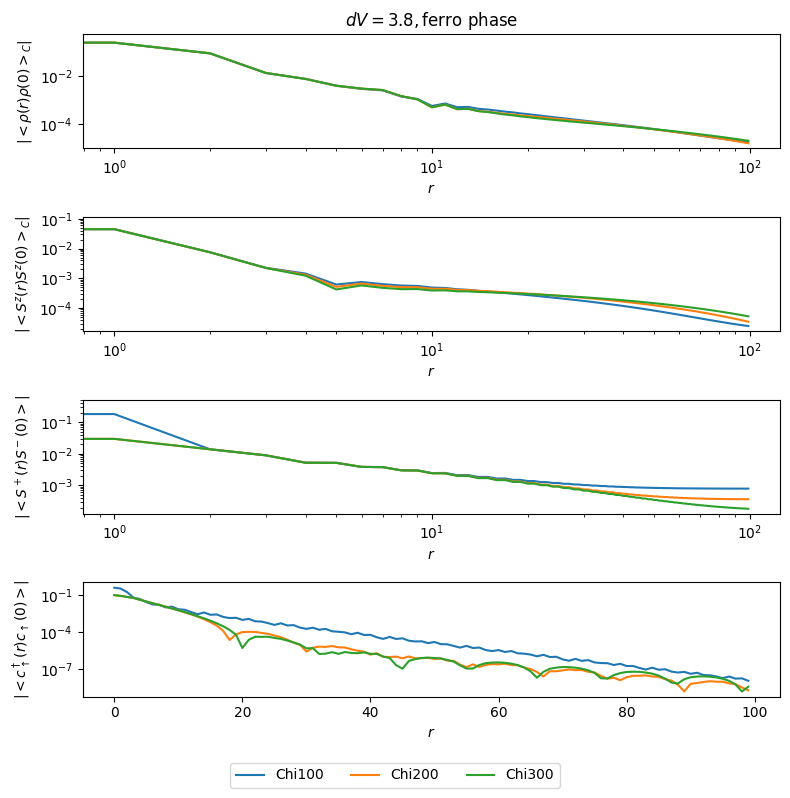

In [77]:
distrangefm = 100
xvalsfm = np.arange(distrangefm)
fig4, ax4 = plt.subplots(4, figsize=(8,8))
fig4.subplots_adjust(hspace=0.2)
#charge
ax4[0].plot(xvalsfm, drp(observables.charge_corr(serfm100['psi'].iloc[0], length=distrangefm, connected=True)), c='C0', label='Chi100')
ax4[0].plot(xvalsfm, drp(observables.charge_corr(serfm200['psi'].iloc[0], length=distrangefm, connected=True)), c='C1', label='Chi200')
ax4[0].plot(xvalsfm, drp(observables.charge_corr(serfm300['psi'].iloc[0], length=distrangefm, connected=True)), c='C2', label='Chi300')
ax4[0].set_yscale('log')
ax4[0].set_xscale('log')
ax4[0].set_xlabel(r'$r$')
# ax4[0].set_ylabel(r'$<\rho(r)\rho(0)> - <\rho(0)>^2 $')
ax4[0].set_ylabel(r'$|<\rho(r)\rho(0)>_C|$')
ax4[0].set_title(rf'$dV = {fmdV:.3}, \text{{ferro phase}}$')
# ax4[0].legend()

#spin
ax4[1].plot(xvalsfm, drp(observables.SzSz_corr(serfm100['psi'].iloc[0], length=distrangefm, connected=True  )), c='C0', label='Chi100')
ax4[1].plot(xvalsfm, drp(observables.SzSz_corr(serfm200['psi'].iloc[0], length=distrangefm, connected=True  )), c='C1', label='Chi200')
ax4[1].plot(xvalsfm, drp(observables.SzSz_corr(serfm300['psi'].iloc[0], length=distrangefm, connected=True  )), c='C2', label='Chi300')
ax4[1].set_yscale('log')
ax4[1].set_xscale('log')
ax4[1].set_xlabel(r'$r$')
# ax4[1].set_ylabel(r'$<S^z(r)S^z(0)> - <S^z(0)>^2 $')
ax4[1].set_ylabel(r'$|<S^z(r)S^z(0)>_C|$')
# ax4[1].set_title(rf'$dV = {fmdV:.3}, \text{{ferro phase}}$')
# ax4[1].legend()

ax4[2].plot(xvalsfm, drp(np.abs(observables.SpSm_corr(serfm100['psi'].iloc[0], length=distrangefm, connected=False))), c='C0', label='Chi100')
ax4[2].plot(xvalsfm, drp(np.abs(observables.SpSm_corr(serfm200['psi'].iloc[0], length=distrangefm, connected=False))), c='C1', label='Chi200')
ax4[2].plot(xvalsfm, drp(np.abs(observables.SpSm_corr(serfm300['psi'].iloc[0], length=distrangefm, connected=False))), c='C2', label='Chi300')
ax4[2].set_yscale('log')
ax4[2].set_xscale('log')
ax4[2].set_xlabel(r'$r$')
ax4[2].set_ylabel(r'$|<S^+(r)S^-(0)>|$')

#electron 
ax4[3].plot(xvalsfm, drp(np.abs(observables.electron_corr(serfm100['psi'].iloc[0], length=distrangefm, whichspin="u"))), c='C0', label='Chi100')
ax4[3].plot(xvalsfm, drp(np.abs(observables.electron_corr(serfm200['psi'].iloc[0], length=distrangefm, whichspin="u"))), c='C1', label='Chi200')
ax4[3].plot(xvalsfm, drp(np.abs(observables.electron_corr(serfm300['psi'].iloc[0], length=distrangefm, whichspin="u"))), c='C2', label='Chi300')
ax4[3].set_yscale('log')
# ax4[3].set_xscale('log')
ax4[3].set_xlabel(r'$r$')
ax4[3].set_ylabel(r'$|<c^\dagger_\uparrow(r)c_\uparrow(0)>|$')
# ax4[2].set_title(rf'$dV = {fmdV:.3}, \text{{ferro phase}}$')
# ax4[2].legend()
handles, labels = ax4[2].get_legend_handles_labels()

fig4.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.0),
           ncol=3)

fig4.tight_layout(rect=[0, 0.05, 1, 1])   
fig4.savefig("../../pngfigs/iDMRG/combinedCorrnfnsferro.png", bbox_inches="tight")

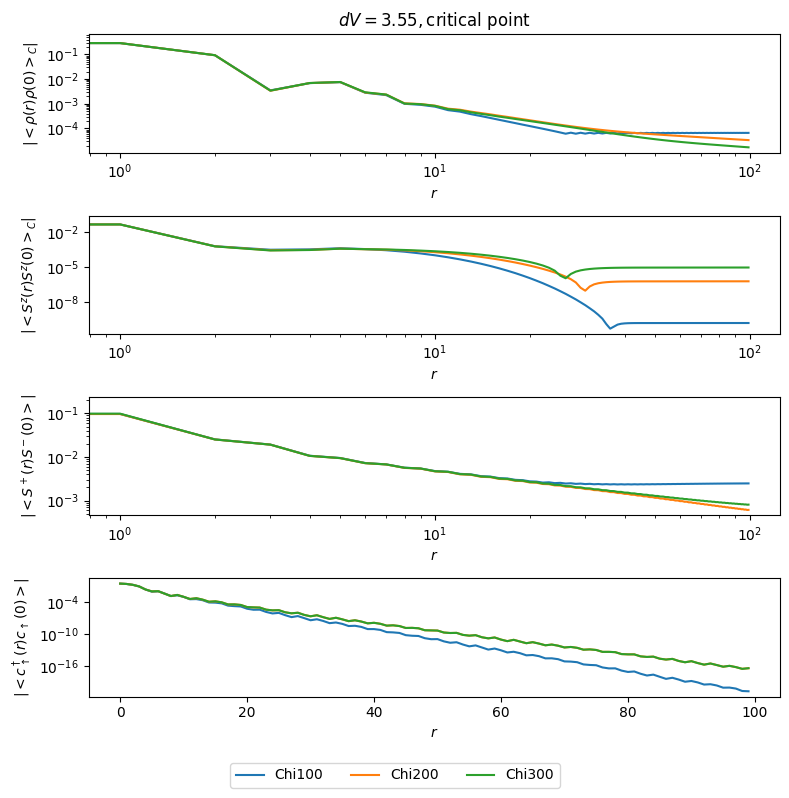

In [76]:
distrangecrit = 100
xvalscrit = np.arange(distrangecrit)
fig5, ax5 = plt.subplots(4, figsize=(8, 8))
fig5.subplots_adjust(hspace=1.0)
#charge
ax5[0].plot(xvalscrit, drp(np.abs(observables.charge_corr(sercrit100['psi'].iloc[0], length=distrangecrit, connected=True))), c='C0', label='Chi100')
ax5[0].plot(xvalscrit, drp(np.abs(observables.charge_corr(sercrit200['psi'].iloc[0], length=distrangecrit, connected=True))), c='C1', label='Chi200')
ax5[0].plot(xvalscrit, drp(np.abs(observables.charge_corr(sercrit300['psi'].iloc[0], length=distrangecrit, connected=True))), c='C2', label='Chi300')
ax5[0].set_yscale('log')
ax5[0].set_xscale('log')
ax5[0].set_xlabel(r'$r$')
ax5[0].set_ylabel(r'$|<\rho(r)\rho(0)>_C|$')
ax5[0].set_title(rf'$dV = {critdV:.3}, \text{{critical point}}$')
# ax5[0].legend()

#spin
ax5[1].plot(xvalscrit, drp(np.abs(observables.SzSz_corr(sercrit100['psi'].iloc[0], length=distrangecrit, connected=False) )), c='C0', label='Chi100')
ax5[1].plot(xvalscrit, drp(np.abs(observables.SzSz_corr(sercrit200['psi'].iloc[0], length=distrangecrit, connected=False) )), c='C1', label='Chi200')
ax5[1].plot(xvalscrit, drp(np.abs(observables.SzSz_corr(sercrit300['psi'].iloc[0], length=distrangecrit, connected=False) )), c='C2', label='Chi300')
ax5[1].set_yscale('log')
ax5[1].set_xscale('log')
ax5[1].set_xlabel(r'$r$')
ax5[1].set_ylabel(r'$|<S^z(r)S^z(0)>_C|$')
# ax5[1].set_title(rf'$dV = {critdV:.3}, \text{{critical point}}$')
# ax5[1].legend()

ax5[2].plot(xvalscrit, drp(np.abs(observables.SpSm_corr(sercrit100['psi'].iloc[0], length=distrangecrit, connected=False))), c='C0', label='Chi100')
ax5[2].plot(xvalscrit, drp(np.abs(observables.SpSm_corr(sercrit200['psi'].iloc[0], length=distrangecrit, connected=False))), c='C1', label='Chi200')
ax5[2].plot(xvalscrit, drp(np.abs(observables.SpSm_corr(sercrit300['psi'].iloc[0], length=distrangecrit, connected=False))), c='C2', label='Chi300')
ax5[2].set_yscale('log')
ax5[2].set_xscale('log')
ax5[2].set_xlabel(r'$r$')
ax5[2].set_ylabel(r'$|<S^+(r)S^-(0)>|$')

#electron 
ax5[3].plot(xvalscrit, drp(np.abs(observables.electron_corr(sercrit100['psi'].iloc[0], length=distrangecrit, whichspin="u"))), c='C0', label='Chi100')
ax5[3].plot(xvalscrit, drp(np.abs(observables.electron_corr(sercrit300['psi'].iloc[0], length=distrangecrit, whichspin="u"))), c='C1', label='Chi200')
ax5[3].plot(xvalscrit, drp(np.abs(observables.electron_corr(sercrit300['psi'].iloc[0], length=distrangecrit, whichspin="u"))), c='C2', label='Chi300')
ax5[3].set_yscale('log')
# ax5[3].set_xscale('log')
ax5[3].set_xlabel(r'$r$')
ax5[3].set_ylabel(r'$|<c^\dagger_\uparrow(r)c_\uparrow(0)>| $')
# ax5[3].set_title(rf'$dV = {critdV:.3}, \text{{critical point}}$')
# ax5[3].legend()

handles, labels = ax5[3].get_legend_handles_labels()

fig5.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.0),
           ncol=3)

fig5.tight_layout(rect=[0, 0.05, 1, 1])  
fig5.savefig("../../pngfigs/iDMRG/combinedCorrnfnsCrit.png", bbox_inches="tight")